# ДЗ №2 — Triton LayerNorm (Colab)

**Перед запуском:**
1. Runtime → Change runtime type → **GPU** (L4 / A100 / T4).
2. Перетащи файл `task2.py` в панель Files слева (значок папки).
3. Прогоняй ячейки сверху вниз.

На T4 (sm_75) bf16 эмулируется — будет медленнее, чем torch eager. На L4/A100 Triton должен обгонять или быть на уровне eager.

In [1]:
!nvidia-smi -L

GPU 0: Tesla T4 (UUID: GPU-b3505ca5-5c59-e86c-4c38-935b39f49604)


In [2]:
import torch, triton, sys
print('python  :', sys.version.split()[0])
print('torch   :', torch.__version__)
print('triton  :', triton.__version__)
print('cuda    :', torch.version.cuda)
print('device  :', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'NO CUDA')
assert torch.cuda.is_available(), 'Включи GPU runtime!'

python  : 3.12.13
torch   : 2.10.0+cu128
triton  : 3.6.0
cuda    : 12.8
device  : Tesla T4


In [4]:
# проверка, что task2.py загружен
import os
assert os.path.exists('task2.py'), 'Перетащи task2.py в панель Files слева и перезапусти ячейку'
print('task2.py найден,', os.path.getsize('task2.py'), 'байт')

task2.py найден, 13208 байт


In [6]:
# correctness
import importlib, sys
sys.path.insert(0, '.')
if 'task2' in sys.modules:
    importlib.reload(sys.modules['task2'])
import task2
task2._check_correctness()

ok  shape=(8, 512, 1024) dtype=torch.float32
ok  shape=(8, 512, 1024) dtype=torch.bfloat16
ok  shape=(4, 128, 199) dtype=torch.bfloat16
ok  shape=(2, 64, 1023) dtype=torch.float32
ok  shape=(16, 256, 4096) dtype=torch.bfloat16


/usr/local/lib/python3.12/dist-packages/torch/_inductor/compile_fx.py:2900: UserWarning: Tesla T4 does not support bfloat16 compilation natively, skipping
  warnings.warn(


layernorm_fwd_bf16_M4096:
        N  triton (GB/s)  torch-eager (GB/s)  torch-compile (GB/s)
0   512.0     203.054988          187.782230             78.627474
1  1024.0     215.578957          190.477021            220.057924
2  2048.0     236.592046          227.210402            227.210402
3  4096.0     237.853230          174.726269            174.908430
4  8192.0     235.054013          163.431422            163.307332
layernorm_fwd_bwd_bf16_M4096:
        N  triton (GB/s)  torch-eager (GB/s)  torch-compile (GB/s)
0   512.0     105.567014          138.378372            138.378372
1  1024.0      96.206692          156.597373            156.972459
2  2048.0      93.157075          149.165812            149.280490
3  4096.0     110.181571          122.815716            122.807089
4  8192.0     104.623241          119.313639            119.415555


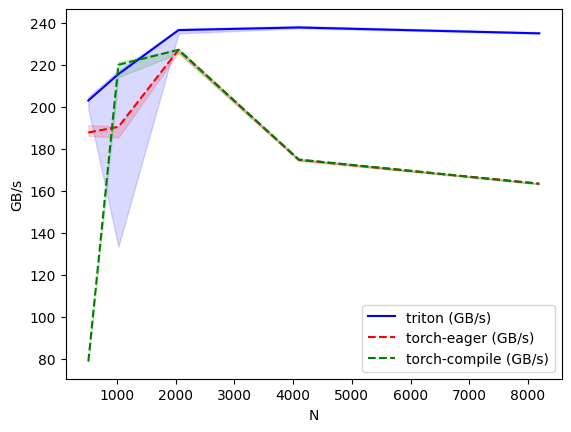

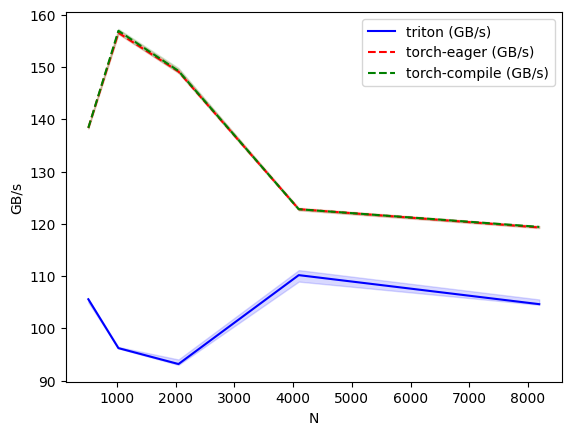

In [7]:
# benchmark — отдельно forward, потом forward+backward
# autotune на первом прогоне тратит пару секунд на каждый N — это норма
task2.run_benchmark()

layernorm_fwd_bf16_M4096.png


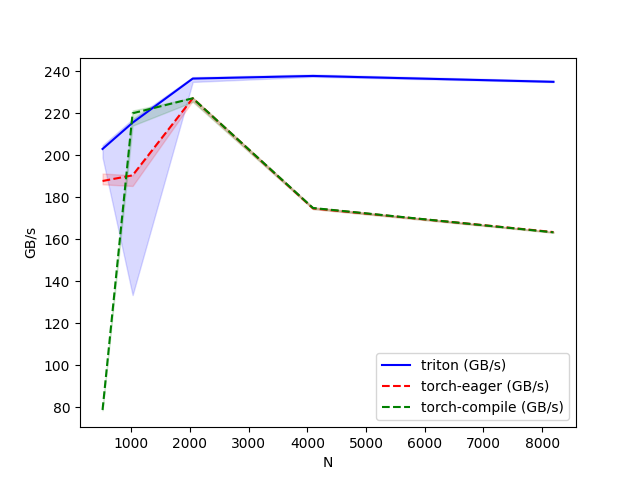

layernorm_fwd_bwd_bf16_M4096.png


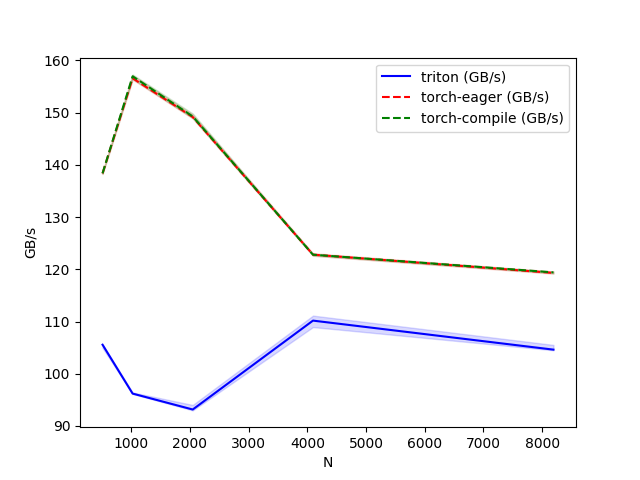

In [8]:
# показать сохранённые PNG inline
from IPython.display import Image, display
import glob
for p in sorted(glob.glob('layernorm_*.png')):
    print(p)
    display(Image(p))

In [9]:

# скачать PNG локально (по желанию — приложить к сдаче)
from google.colab import files
import glob
for p in sorted(glob.glob('layernorm_*.png')):
    files.download(p)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>